In [110]:
# - Pandas
# - Numpy
# - Matplotlib
# - Seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


### 1. Data load and Initial EDA

In [111]:
# First lets load the data into a dataframe
df = pd.read_csv('./insurance.csv')

# Create a new column 'insurance_cost_binary'
# 0 if insurance_cost is less than or equal to the median insurance cost
# 1 otherwise
median_insurance_cost = df['insurance_cost'].median()
df['insurance_cost_binary'] = (df['insurance_cost'] > median_insurance_cost).astype(int)
# remove the original insurance_cost column
df.drop(columns=['insurance_cost'], inplace=True)

df.head()


,age,gender,bmi,children,smoker,region,insurance_cost_binary
0,18,male,33.770,1,no,southeast,0
1,18,male,34.100,0,no,southeast,0
2,18,female,26.315,0,no,northeast,0
3,18,female,38.665,2,no,northeast,0
4,18,female,35.625,0,no,northeast,0


In [112]:
# print the data types of the columns
print("Data types of the columns:") 
print(df.dtypes)


# Display dataset shape
print('\nDataset shape:', df.shape)

Data types of the columns:
age                        int64
gender                       str
bmi                      float64
children                   int64
smoker                       str
region                       str
insurance_cost_binary      int64
dtype: object

Dataset shape: (1338, 7)


### Missing Values

In [113]:
# Lets see if there are any missing values
df.isna().sum()

age                      0
gender                   0
bmi                      0
children                 0
smoker                   0
region                   0
insurance_cost_binary    0
dtype: int64

### Categorical Attributes

In [114]:
# Frequency counts for categorical attributes
categorical_attributes  = df.select_dtypes(include=['str']).columns

print("\nCategorical attributes:\n")
print(list(categorical_attributes))

print("\nFrequency counts for categorical attributes:\n")

for column in categorical_attributes: 
    print("\n")
    print(df[column].value_counts(dropna=False))
    print("--------------------------------")


Categorical attributes:

['gender', 'smoker', 'region']

Frequency counts for categorical attributes:



gender
male      676
female    662
Name: count, dtype: int64
--------------------------------


smoker
no     1064
yes     274
Name: count, dtype: int64
--------------------------------


region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64
--------------------------------


### Numerical Attributes

In [115]:
# Lets look at the summary statistics for numerical attributes

print("\nSummary statistics for numeric attributes:\n")

df.describe()


Summary statistics for numeric attributes:



,age,bmi,children,insurance_cost_binary
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,0.500000
std,14.049960,6.098187,1.205493,0.500187
min,18.000000,15.960000,0.000000,0.000000
25%,27.000000,26.296250,0.000000,0.000000
50%,39.000000,30.400000,1.000000,0.500000
75%,51.000000,34.693750,2.000000,1.000000
max,64.000000,53.130000,5.000000,1.000000


                            age       bmi  children  insurance_cost_binary
age                    1.000000  0.109272  0.042469               0.512617
bmi                    0.109272  1.000000  0.012759               0.089896
children               0.042469  0.012759  1.000000               0.019227
insurance_cost_binary  0.512617  0.089896  0.019227               1.000000


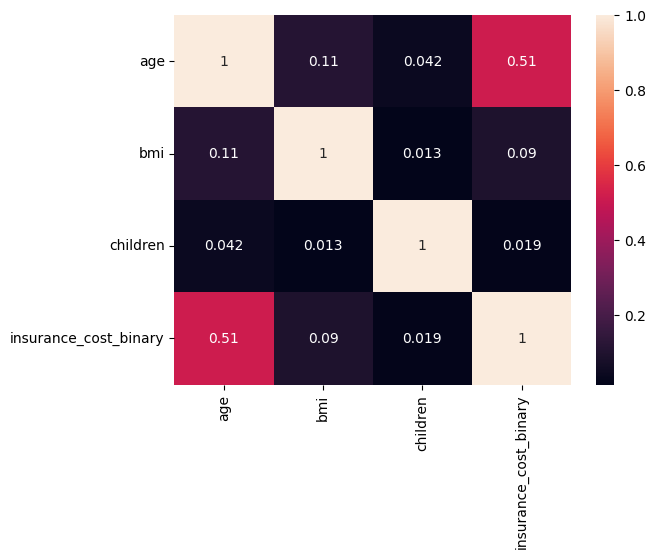

In [116]:
# correlation matrix
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True)
print(corr_matrix)

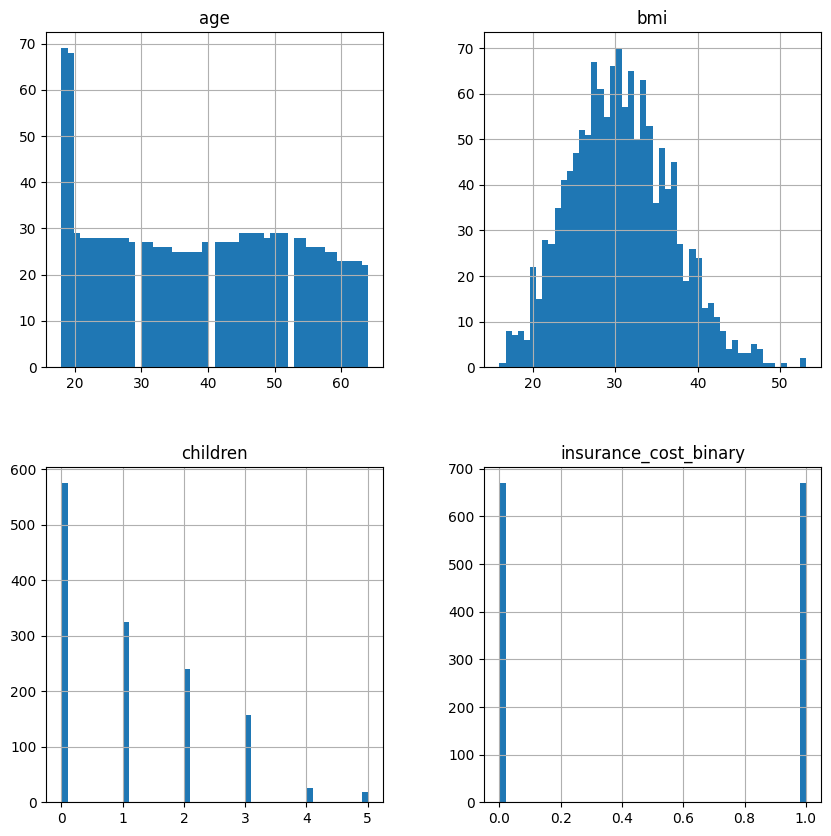

In [117]:
df.hist(bins=50, figsize=(10, 10))
plt.show()

<Axes: >

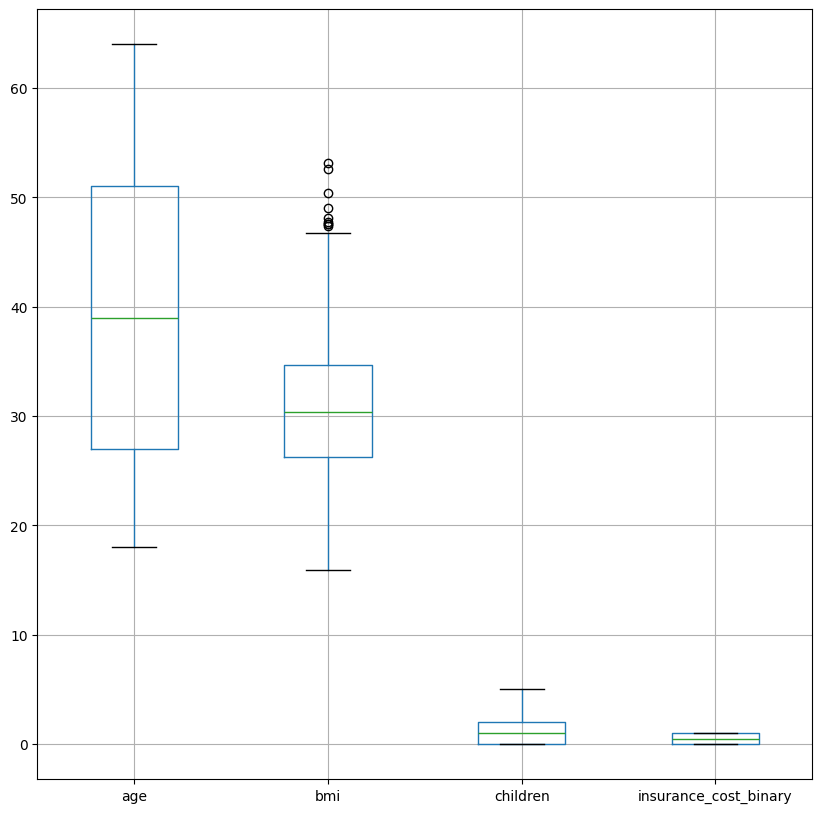

In [118]:
df.boxplot(figsize=(10, 10))

### Summary of Inital EDA

The dataset looks quite clean with only a small amount of columns and no missing data.

Observations:
1. bmi is the only column that has any real outliers as seen from the box plots.
2. There is some moderate correlation between age and insurance_cost_binary
3. There is a slight positive correlation between bmi and insurance_cost_binary
4. There are 3 categorical attributes: 'gender', 'smoker' and 'region'
5. age looks uniformly distributed aprt from ages under < 20
6. bmi looks like its normally distributed.
7. children appears to be right skewed.




### 2. Create Pipelines

numerical_attributes =  Index(['age', 'bmi', 'children', 'insurance_cost_binary'], dtype='str')
categorical_attributes =  Index(['gender', 'smoker', 'region'], dtype='str')
['categorical_pipeline__gender_female' 'categorical_pipeline__gender_male'
 'categorical_pipeline__smoker_no' 'categorical_pipeline__smoker_yes'
 'categorical_pipeline__region_northeast'
 'categorical_pipeline__region_northwest'
 'categorical_pipeline__region_southeast'
 'categorical_pipeline__region_southwest' 'age_pipeline__age'
 'bmi_pipeline__bmi' 'children_pipeline__children']


,categorical_pipeline__gender_female,categorical_pipeline__gender_male,categorical_pipeline__smoker_no,categorical_pipeline__smoker_yes,categorical_pipeline__region_northeast,categorical_pipeline__region_northwest,categorical_pipeline__region_southeast,categorical_pipeline__region_southwest,age_pipeline__age,bmi_pipeline__bmi,children_pipeline__children
0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.509621,0.693147
1,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.563756,0.000000
2,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,-0.713331,0.000000
3,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.312619,1.098612
4,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.813924,0.000000
5,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.166768,1.098612
6,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,-0.089961,0.000000
7,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,-1.134105,0.000000
8,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,-0.900341,0.000000
9,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.014878,0.000000


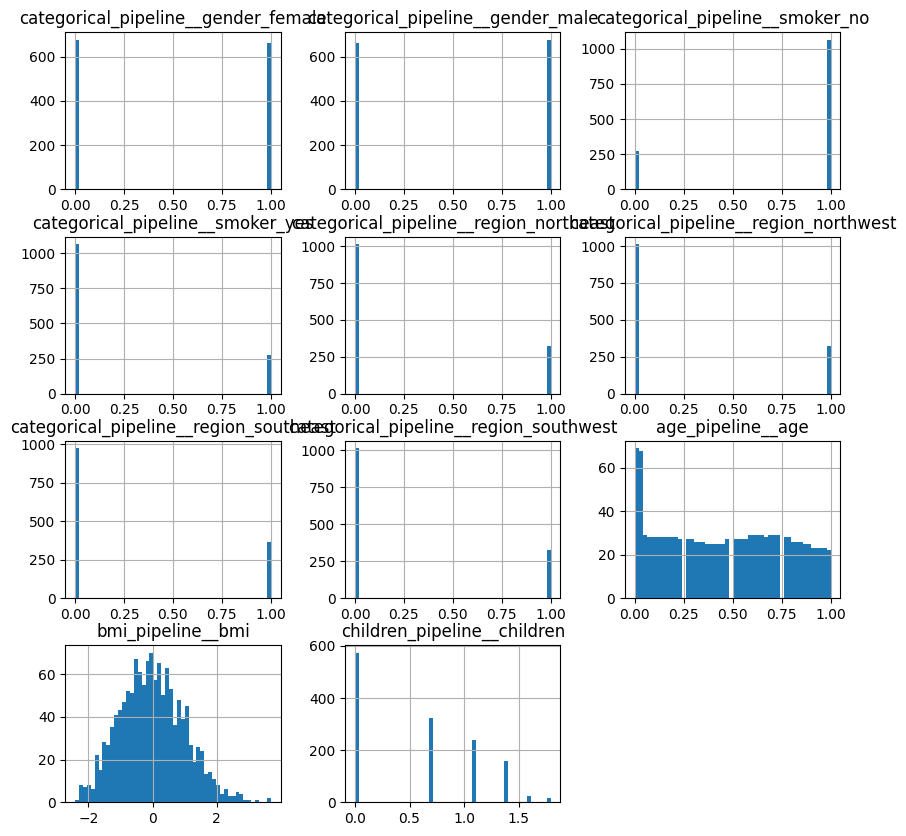

In [ ]:
def log_transform(x):
    return np.log(x+1)

# Create a pipeline for the categorical attributes
categorical_pipeline = Pipeline(
    [
        ('one_hot_encoder', OneHotEncoder())
    ]
)

numerical_attributes = df.select_dtypes(include=['float64', 'int64']).columns

print("numerical_attributes = ", numerical_attributes)
print("categorical_attributes = ", categorical_attributes)

log_pipeline = Pipeline(
    [
        ('log_transformer', FunctionTransformer(log_transform, feature_names_out='one-to-one'))
    ]
)

bmi_pipeline = Pipeline(
    [
        ('standard_scaler', StandardScaler())
    ]
)

age_pipeline = Pipeline(
    [
        ('passthrough', 'passthrough')
    ]
)

plt.show()

# Combine the pipelines
preprocessing_pipeline = ColumnTransformer(
    [
        ('categorical_pipeline', categorical_pipeline, categorical_attributes),
        ('age_pipeline', age_pipeline, ['age']),
        ('bmi_pipeline', bmi_pipeline, ['bmi']),
        ('children_pipeline', log_pipeline, ['children']), 
    ]
)

prepared = preprocessing_pipeline.fit_transform(df)

print(preprocessing_pipeline.get_feature_names_out())

df_prepared = pd.DataFrame(prepared, columns=preprocessing_pipeline.get_feature_names_out(), index=df.index)

df_prepared.hist(bins=50, figsize=(10, 10), )


df_prepared.head(20)
